In [5]:
%pip install category_encoders

## 📦 Libraries and Dependencies



In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report
from category_encoders import BinaryEncoder


## 📁 Data Loading and Initial Exploration

### 🔽 Loading the Dataset


In [7]:
df= pd.read_csv('HeartDiseaseTrain-Test.csv')
df

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1


oldpeak-->slope
when we have a high val in oldpeak this means we have high depressdepression
which have a relation with the slope (high depressdepression --> downsloping) not always the case

## 🔍 Data Exploration and Analysis

### 📊 Quick Data Preview


In [8]:
df.head(20)

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
5,58,Female,Typical angina,100,248,Lower than 120 mg/ml,Normal,122,No,1.0,Flat,Zero,Fixed Defect,1
6,58,Male,Typical angina,114,318,Lower than 120 mg/ml,Left ventricular hypertrophy,140,No,4.4,Upsloping,Three,Normal,0
7,55,Male,Typical angina,160,289,Lower than 120 mg/ml,Normal,145,Yes,0.8,Flat,One,Reversable Defect,0
8,46,Male,Typical angina,120,249,Lower than 120 mg/ml,Normal,144,No,0.8,Downsloping,Zero,Reversable Defect,0
9,54,Male,Typical angina,122,286,Lower than 120 mg/ml,Normal,116,Yes,3.2,Flat,Two,Fixed Defect,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [10]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [11]:
df.shape

(1025, 14)

In [12]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [13]:
df.value_counts('slope')

,count
slope,
Flat,482
Downsloping,469
Upsloping,74


## 🎯 Data Preparation and Splitting

### 🎯 Target Variable Separation



In [14]:
Y=pd.DataFrame(df['target'])
X=df.drop(columns='target',axis=1)

In [15]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,shuffle=True ,random_state=24)
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,shuffle=True,random_state=24)

In [16]:
x_train
y_train
x_train
y_val
x_train
y_test

,target
68,1
16,1
197,1
1024,0
349,0
...,...
81,0
756,0
98,0
640,1


## 🔧 Binary Encoding for Categorical Variables



## 🎯 Complete Feature Encoding Strategy

### 📊 Comprehensive Encoding Plan

#### 🔁 **Binary Encoded Features**
| Feature | Encoding Method | Reason |
|---------|----------------|---------|
| `sex` | Binary Encoding | Binary categorical (Male/Female) |
| `fasting_blood_sugar` | Binary Encoding | Binary categorical (True/False) |
| `exercise_induced_angina` | Binary Encoding | Binary categorical (Yes/No) |

#### 🏷️ **Label Encoded Features**
| Feature | Encoding Method | Reason |
|---------|----------------|---------|
| `slope` | Label Encoding | Ordinal categorical (ordered categories) |
| `vessels_colored_by_flourosopy` | Label Encoding | Ordinal numerical (0, 1, 2, 3, 4) |

#### 🔥 **One-Hot Encoded Features**
| Feature | Encoding Method | Reason |
|---------|----------------|---------|
| `chest_pain_type` | One-Hot Encoding | Nominal categorical (no natural order) |
| `rest_ecg` | One-Hot Encoding | Nominal categorical (ECG results) |
| `thalassemia` | One-Hot Encoding | Nominal categorical (blood disorder types) |

### 📋 Detailed Encoding Rationale

#### 🔁 **Binary Encoding (sex, fasting_blood_sugar, exercise_induced_angina)**
- **Characteristics**: Binary categorical variables with only 2 possible values
- **Efficiency**: Binary encoding creates minimal additional columns
- **Memory**: Most memory-efficient for binary features
- **Examples**:
  - `sex`: Male=1, Female=0
  - `fasting_blood_sugar`: High=True, Normal=False
  - `exercise_induced_angina`: Yes=1, No=0

#### 🏷️ **Label Encoding (slope, vessels_colored_by_flourosopy)**
- **Characteristics**: Ordinal categorical variables with meaningful order
- **Preservation**: Maintains numerical relationship between categories
- **Efficiency**: Single column output (no dimensionality increase)
- **Examples**:
  - `slope`: Upsloping < Flat < Downsloping
  - `vessels_colored_by_flourosopy`: 0 < 1 < 2 < 3 (number of vessels)

#### 🔥 **One-Hot Encoding (chest_pain_type, rest_ecg, thalassemia)**
- **Characteristics**: Nominal categorical variables with no natural ordering
- **Prevention**: Avoids algorithm assumptions about category relationships
- **Completeness**: Preserves all categorical information
- **Examples**:
  - `chest_pain_type`: Asymptomatic, Atypical, Non-anginal, Typical
  - `rest_ecg`: Normal, Abnormal, Probable
  - `thalassemia`: Normal, Fixed, Reversible, Unknown

### 🎯 Encoding Strategy Benefits

#### 📈 **Optimal Algorithm Performance**
- Each feature encoded with most appropriate method
- Prevents information loss and algorithm bias
- Maintains data integrity across all feature types

#### 💾 **Memory Efficiency**
- Binary encoding for binary features
- Label encoding for ordinal features
- One-hot encoding only where necessary

#### 🔄 **Consistency Across Datasets**
- Same encoding strategy applied to train/validation/test sets
- Prevents data leakage through proper fit/transform workflow
- Maintains feature compatibility across all data splits

### ⚠️ Implementation Considerations
- **Order Matters**: Apply encodings in consistent sequence
- **Pipeline Approach**: Consider sklearn Pipeline for automated preprocessing
- **Feature Names**: Maintain clear column names for interpretability
- **Validation**: Ensure encodings work correctly on all data splits

In [17]:
bi_encoder = BinaryEncoder()
df_encoded = bi_encoder.fit_transform(x_train[['sex', 'fasting_blood_sugar', 'exercise_induced_angina']])
df_encoded

,sex_0,sex_1,fasting_blood_sugar_0,fasting_blood_sugar_1,exercise_induced_angina_0,exercise_induced_angina_1
621,0,1,0,1,0,1
801,0,1,0,1,1,0
515,0,1,1,0,1,0
31,1,0,1,0,1,0
116,0,1,1,0,1,0
...,...,...,...,...,...,...
401,1,0,1,0,1,0
343,0,1,0,1,1,0
192,1,0,1,0,1,0
899,0,1,1,0,1,0


In [18]:
x_train=pd.concat([x_train,df_encoded],axis=1)
x_train.drop('sex',axis=1,inplace=True)
x_train.drop('fasting_blood_sugar',axis=1,inplace=True)
x_train.drop('exercise_induced_angina',axis=1,inplace=True)
x_train

,age,chest_pain_type,resting_blood_pressure,cholestoral,rest_ecg,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,sex_0,sex_1,fasting_blood_sugar_0,fasting_blood_sugar_1,exercise_induced_angina_0,exercise_induced_angina_1
621,48,Typical angina,130,256,Normal,150,0.0,Downsloping,Two,Reversable Defect,0,1,0,1,0,1
801,63,Asymptomatic,145,233,Normal,150,2.3,Upsloping,Zero,Normal,0,1,0,1,1,0
515,49,Non-anginal pain,120,188,ST-T wave abnormality,139,2.0,Flat,Three,Reversable Defect,0,1,1,0,1,0
31,50,Atypical angina,120,244,ST-T wave abnormality,162,1.1,Downsloping,Zero,Fixed Defect,1,0,1,0,1,0
116,63,Typical angina,130,254,Normal,147,1.4,Flat,One,Reversable Defect,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,71,Typical angina,112,149,ST-T wave abnormality,125,1.6,Flat,Zero,Fixed Defect,1,0,1,0,1,0
343,52,Non-anginal pain,172,199,ST-T wave abnormality,162,0.5,Downsloping,Zero,Reversable Defect,0,1,0,1,1,0
192,67,Non-anginal pain,115,564,Normal,160,1.6,Flat,Zero,Reversable Defect,1,0,1,0,1,0
899,59,Typical angina,135,234,ST-T wave abnormality,161,0.5,Flat,Zero,Reversable Defect,0,1,1,0,1,0


In [19]:
df_encoded = bi_encoder.transform(x_val[['sex', 'fasting_blood_sugar', 'exercise_induced_angina']])
x_val=pd.concat([x_val,df_encoded],axis=1)
x_val.drop('sex',axis=1,inplace=True)
x_val.drop('fasting_blood_sugar',axis=1,inplace=True)
x_val.drop('exercise_induced_angina',axis=1,inplace=True)
x_val

,age,chest_pain_type,resting_blood_pressure,cholestoral,rest_ecg,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,sex_0,sex_1,fasting_blood_sugar_0,fasting_blood_sugar_1,exercise_induced_angina_0,exercise_induced_angina_1
249,42,Non-anginal pain,130,180,ST-T wave abnormality,150,0.0,Downsloping,Zero,Fixed Defect,0,1,1,0,1,0
802,63,Typical angina,124,197,ST-T wave abnormality,136,0.0,Flat,Zero,Fixed Defect,1,0,1,0,0,1
369,51,Non-anginal pain,110,175,ST-T wave abnormality,123,0.6,Downsloping,Zero,Fixed Defect,0,1,1,0,1,0
476,57,Typical angina,165,289,Normal,124,1.0,Flat,Three,Reversable Defect,0,1,0,1,1,0
154,63,Typical angina,130,330,Normal,132,1.8,Downsloping,Three,Reversable Defect,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,45,Asymptomatic,110,264,ST-T wave abnormality,132,1.2,Flat,Zero,Reversable Defect,0,1,1,0,1,0
988,60,Typical angina,140,293,Normal,170,1.2,Flat,Two,Reversable Defect,0,1,1,0,1,0
454,65,Typical angina,150,225,Normal,114,1.0,Flat,Three,Reversable Defect,1,0,1,0,1,0
70,59,Typical angina,170,326,Normal,140,3.4,Upsloping,Zero,Reversable Defect,0,1,1,0,0,1


In [20]:
df_encoded = bi_encoder.transform(x_test[['sex', 'fasting_blood_sugar', 'exercise_induced_angina']])
x_test=pd.concat([x_test,df_encoded],axis=1)
x_test.drop('sex',axis=1,inplace=True)
x_test.drop('fasting_blood_sugar',axis=1,inplace=True)
x_test.drop('exercise_induced_angina',axis=1,inplace=True)
x_test

,age,chest_pain_type,resting_blood_pressure,cholestoral,rest_ecg,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,sex_0,sex_1,fasting_blood_sugar_0,fasting_blood_sugar_1,exercise_induced_angina_0,exercise_induced_angina_1
68,37,Non-anginal pain,120,215,ST-T wave abnormality,170,0.0,Downsloping,Zero,Fixed Defect,1,0,1,0,1,0
16,51,Non-anginal pain,140,308,Normal,142,1.5,Downsloping,One,Fixed Defect,1,0,1,0,1,0
197,45,Typical angina,115,260,Normal,185,0.0,Downsloping,Zero,Fixed Defect,0,1,1,0,1,0
1024,54,Typical angina,120,188,ST-T wave abnormality,113,1.4,Flat,One,Reversable Defect,0,1,1,0,1,0
349,62,Non-anginal pain,130,263,ST-T wave abnormality,97,1.2,Flat,One,Reversable Defect,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,49,Non-anginal pain,118,149,Normal,126,0.8,Downsloping,Three,Fixed Defect,0,1,1,0,1,0
756,64,Typical angina,120,246,Normal,96,2.2,Upsloping,One,Fixed Defect,0,1,1,0,0,1
98,65,Typical angina,110,248,Normal,158,0.6,Downsloping,Two,Normal,0,1,1,0,1,0
640,46,Typical angina,138,243,Normal,152,0.0,Flat,Zero,Fixed Defect,1,0,1,0,0,1


## 🏷️ Label Encoding for Ordinal Features

### 📊 Ordinal Features Requiring Label Encoding


### 🔍 Detailed Feature Analysis

#### 📈 **Slope Feature**


In [21]:
lencoder=LabelEncoder()
x_train['slope']=lencoder.fit_transform(x_train['slope'])
x_val['slope']=lencoder.transform(x_val['slope'])
x_test['slope']=lencoder.transform(x_test['slope'])



## 🏷️ Label Encoding for Vessels Colored by Fluoroscopy

### 🔁 Apply Label Encoding to Vessels Feature


In [22]:
x_train['vessels_colored_by_flourosopy']=lencoder.fit_transform(x_train['vessels_colored_by_flourosopy'])
x_val['vessels_colored_by_flourosopy']=lencoder.transform(x_val['vessels_colored_by_flourosopy'])
x_test['vessels_colored_by_flourosopy']=lencoder.transform(x_test['vessels_colored_by_flourosopy'])

## 🔥 One-Hot Encoding for Nominal Categorical Features



### 📊 Feature Encoding Summary

#### 🔄 **One-Hot Encoded Features**
| Feature | Encoding Method | Reason |
|---------|----------------|---------|
| `chest_pain_type` | One-Hot Encoding | Nominal categorical variable with no natural ordering |
| `rest_ecg` | One-Hot Encoding | Nominal categorical variable representing ECG results |
| `thalassemia` | One-Hot Encoding | Nominal categorical variable for blood disorder types |

### 🎯 Encoding Rationale

#### 🫀 **Chest Pain Type (`chest_pain_type`)**
- **Nature**: Nominal categorical (typically values: 0, 1, 2, 3, 4)
- **Values**: Different types of chest pain (asymptomatic, atypical angina, non-anginal pain, typical angina)
- **Why One-Hot**: No inherent order between pain types

#### 💓 **Rest ECG (`rest_ecg`)**
- **Nature**: Nominal categorical (typically values: 0, 1, 2)
- **Values**: Resting electrocardiographic results
- **Why One-Hot**: ECG categories don't have meaningful numerical relationship

#### 🩸 **Thalassemia (`thalassemia`)**
- **Nature**: Nominal categorical (typically values: 0, 1, 2, 3)
- **Values**: Blood disorder categories
- **Why One-Hot**: Thalassemia types don't follow numerical ordering

### 📈 One-Hot Encoding Benefits
- **Prevents Ordinal Assumptions**: Algorithms won't assume category 2 > category 1
- **Preserves Information**: All categorical information maintained
- **Algorithm Compatibility**: Works well with all ML algorithms
- **Interpretability**: Clear separation of category effects

### ⚠️ Considerations
- **Dimensionality Increase**: Creates multiple binary columns per feature
- **Multicollinearity**: May introduce correlated features (consider dropping first category)
- **Memory Usage**: Increases dataset size, especially with high-cardinality features

In [23]:
onehot=OneHotEncoder()

df_encoded = onehot.fit_transform(x_train[['chest_pain_type','rest_ecg','thalassemia']])
df_encoded = pd.DataFrame(df_encoded.toarray(), columns=onehot.get_feature_names_out(['chest_pain_type','rest_ecg','thalassemia']))
x_train = x_train.reset_index(drop=True)
x_train=pd.concat([x_train,df_encoded],axis=1)
x_train.drop(['chest_pain_type','rest_ecg','thalassemia'], axis=1, inplace=True)
x_train

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,sex_0,sex_1,fasting_blood_sugar_0,...,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Left ventricular hypertrophy,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,thalassemia_Fixed Defect,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,48,130,256,150,0.0,0,3,0,1,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,63,145,233,150,2.3,2,4,0,1,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,49,120,188,139,2.0,1,2,0,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,50,120,244,162,1.1,0,4,1,0,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,63,130,254,147,1.4,1,1,0,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,71,112,149,125,1.6,1,4,1,0,1,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
713,52,172,199,162,0.5,0,4,0,1,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
714,67,115,564,160,1.6,1,4,1,0,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
715,59,135,234,161,0.5,1,4,0,1,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [24]:
df_encoded

,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Left ventricular hypertrophy,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,thalassemia_Fixed Defect,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
712,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
713,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
714,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
715,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [25]:
df_encoded = onehot.transform(x_val[['chest_pain_type','rest_ecg','thalassemia']])
df_encoded = pd.DataFrame(df_encoded.toarray(), columns=onehot.get_feature_names_out(['chest_pain_type','rest_ecg','thalassemia']))
x_val = x_val.reset_index(drop=True)
x_val=pd.concat([x_val,df_encoded],axis=1)
x_val.drop('chest_pain_type',axis=1,inplace=True)
x_val.drop('rest_ecg',axis=1,inplace=True)
x_val.drop('thalassemia',axis=1,inplace=True)
x_val

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,sex_0,sex_1,fasting_blood_sugar_0,...,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Left ventricular hypertrophy,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,thalassemia_Fixed Defect,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,42,130,180,150,0.0,0,4,0,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,63,124,197,136,0.0,1,4,1,0,1,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,51,110,175,123,0.6,0,4,0,1,1,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,57,165,289,124,1.0,1,2,0,1,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,63,130,330,132,1.8,0,2,0,1,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,45,110,264,132,1.2,1,4,0,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
150,60,140,293,170,1.2,1,3,0,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
151,65,150,225,114,1.0,1,2,1,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
152,59,170,326,140,3.4,2,4,0,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [26]:
df_encoded = onehot.transform(x_test[['chest_pain_type','rest_ecg','thalassemia']])
df_encoded = pd.DataFrame(df_encoded.toarray(), columns=onehot.get_feature_names_out(['chest_pain_type','rest_ecg','thalassemia']))
x_test = x_test.reset_index(drop=True)
x_test=pd.concat([x_test,df_encoded],axis=1)
x_test.drop('chest_pain_type',axis=1,inplace=True)
x_test.drop('rest_ecg',axis=1,inplace=True)
x_test.drop('thalassemia',axis=1,inplace=True)
x_test

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,sex_0,sex_1,fasting_blood_sugar_0,...,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Left ventricular hypertrophy,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,thalassemia_Fixed Defect,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,37,120,215,170,0.0,0,4,1,0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,51,140,308,142,1.5,0,1,1,0,1,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,45,115,260,185,0.0,0,4,0,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,54,120,188,113,1.4,1,1,0,1,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,130,263,97,1.2,1,1,1,0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,49,118,149,126,0.8,0,2,0,1,1,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
150,64,120,246,96,2.2,2,1,0,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
151,65,110,248,158,0.6,0,3,0,1,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
152,46,138,243,152,0.0,1,4,1,0,1,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


**Purpose**: Identify numerical features requiring standardization
**Features**:
- `age`: Patient age in years
- `resting_blood_pressure`: Resting blood pressure (mm Hg)
- `cholestoral`: Serum cholesterol (mg/dl)
- `Max_heart_rate`: Maximum heart rate achieved
- `oldpeak`: ST depression induced by exercise relative to rest



## 📏 Feature Scaling for Numerical Variables

### 📊 Scaling Columns


In [27]:
scaler=StandardScaler()
x_train[['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']]=scaler.fit_transform(x_train[['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']])

In [28]:
x_val[['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']]=scaler.transform(x_val[['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']])

In [29]:
x_test[['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']]=scaler.transform(x_test[['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']])

## 📊 Correlation Analysis and Heatmap Visualization

### 🔍 Calculate Correlation Matrix


<Axes: >

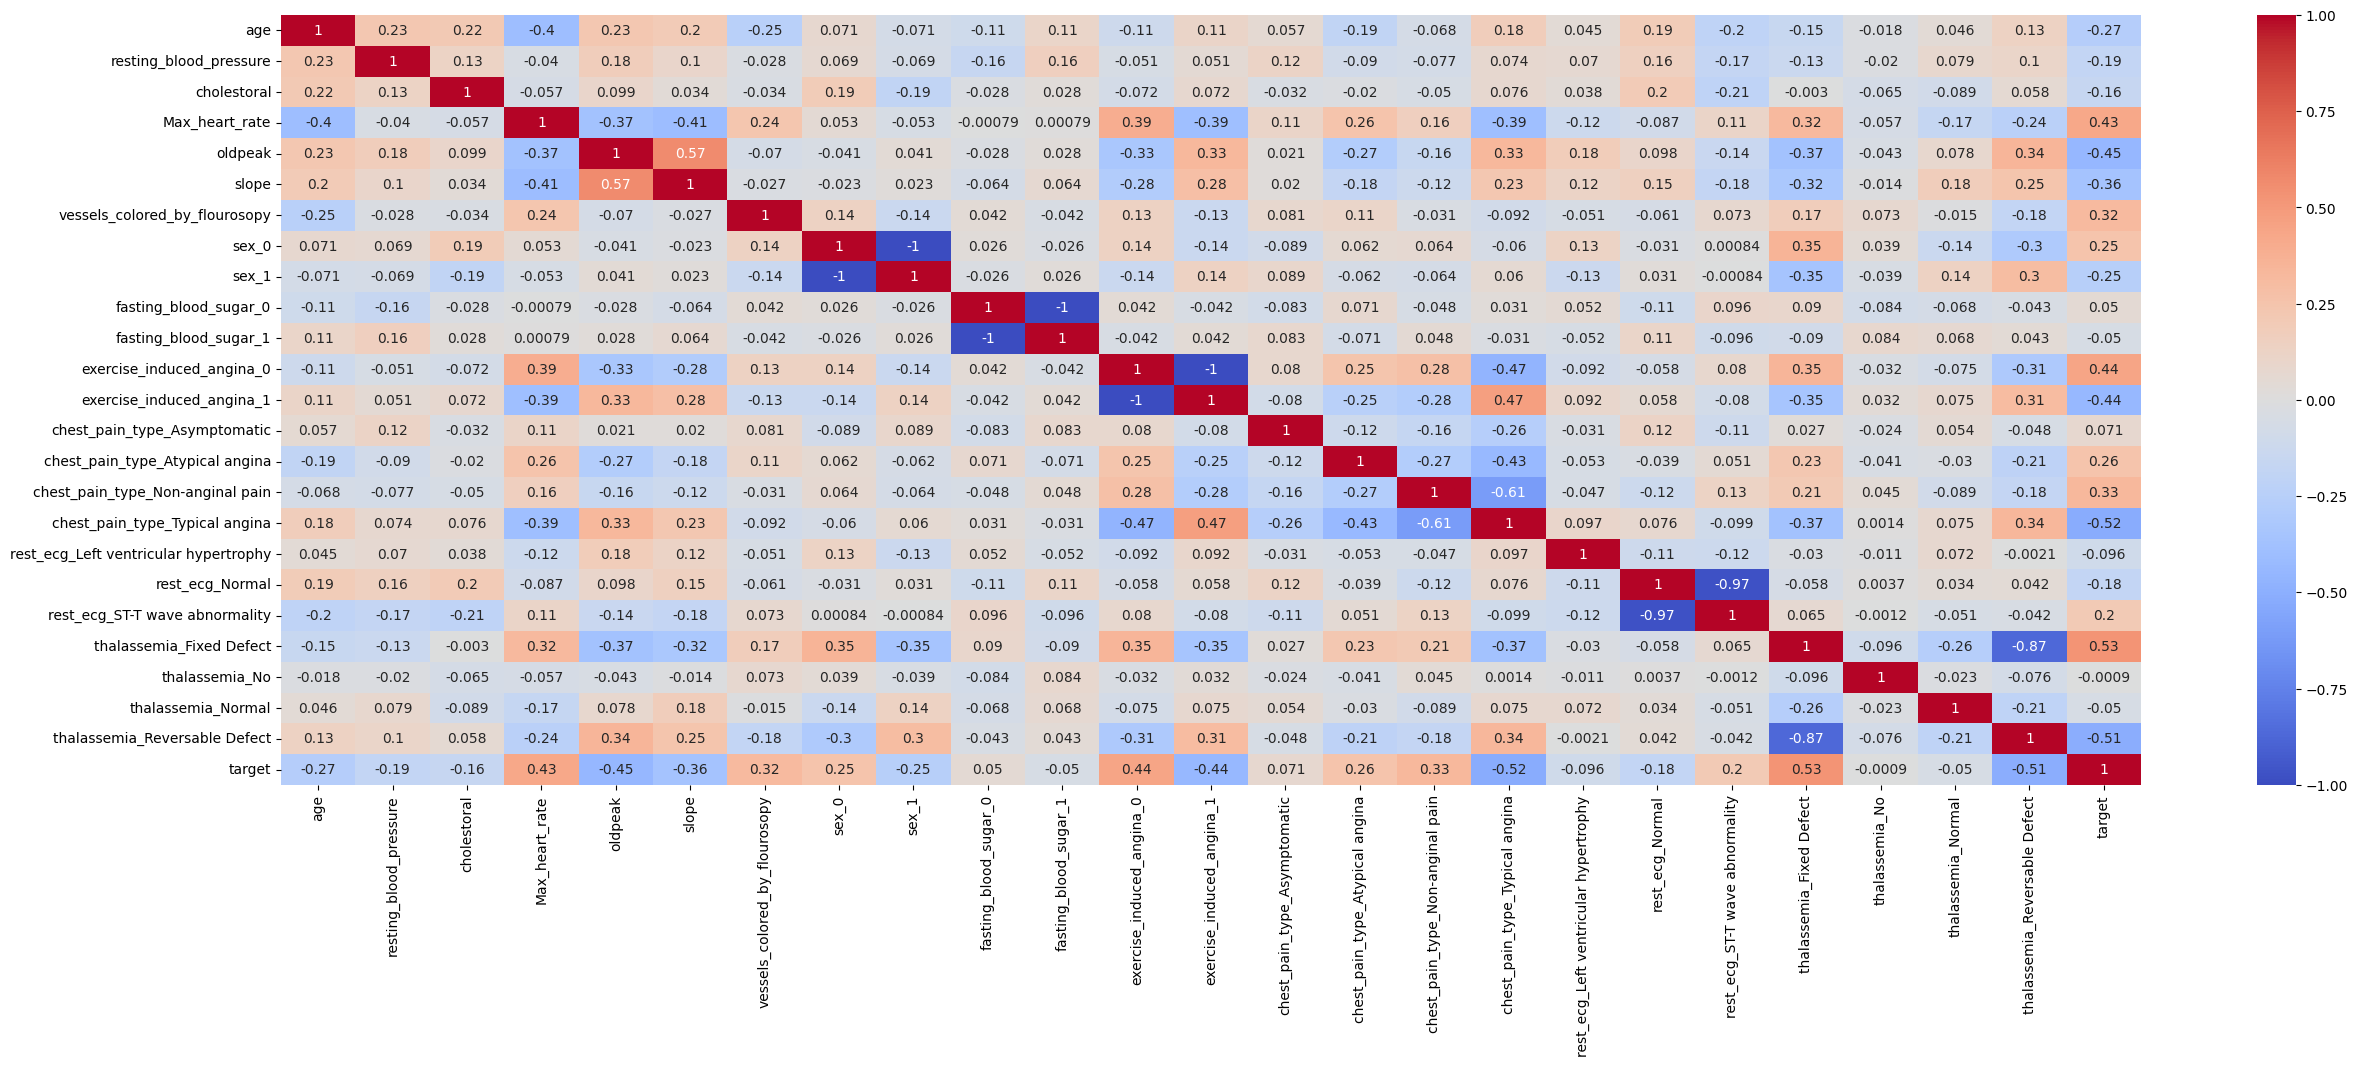

In [30]:
y_train = y_train.reset_index(drop=True)
y_train.index = y_train.index
df = pd.concat([x_train,y_train],axis=1)
corr = df .corr()
plt.figure(figsize=(30,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")

## 🎯 Comprehensive Feature Selection Pipeline

### 📊 Low Target Correlation Feature Removal



In [31]:
threshold_target=0.05
target_corr=df.corr()['target']
low_corr_features = target_corr[abs(target_corr) < threshold_target].index
print("Features with low correlation to the target:")
print(low_corr_features)
x_train = x_train.drop(columns=[col for col in low_corr_features if col])
x_val = x_val.drop(columns=[col for col in low_corr_features ])
x_test = x_test.drop(columns=[col for col in low_corr_features ])

x_train


Features with low correlation to the target:
Index(['fasting_blood_sugar_0', 'fasting_blood_sugar_1', 'thalassemia_No',
       'thalassemia_Normal'],
      dtype='object')


,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,sex_0,sex_1,exercise_induced_angina_0,exercise_induced_angina_1,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Left ventricular hypertrophy,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,thalassemia_Fixed Defect,thalassemia_Reversable Defect
0,-0.693518,-0.104073,0.180373,-0.000060,-0.906247,0,3,0,1,0,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.959948,0.763602,-0.264650,-0.000060,1.102208,2,4,0,1,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.583287,-0.682522,-1.135349,-0.472495,0.840236,1,2,0,1,1,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.473056,-0.682522,-0.051813,0.515324,0.054319,0,4,1,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.959948,-0.104073,0.141676,-0.128906,0.316291,1,1,0,1,1,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,1.841796,-1.145282,-1.889955,-1.073776,0.490939,1,4,1,0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
713,-0.252594,2.325416,-0.922512,0.515324,-0.469626,0,4,0,1,1,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
714,1.400872,-0.971747,6.139823,0.429427,0.490939,1,4,1,0,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
715,0.519024,0.185152,-0.245301,0.472375,-0.469626,1,4,0,1,1,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 🔍 High Correlation Feature Removal (Duplicated/Multicollinear Features)

In [32]:
threshold_feature=0.9
corr_matrix_filtered = x_train.corr().abs()
upper_triangle = corr_matrix_filtered.where(
    np.triu(np.ones(corr_matrix_filtered.shape), k=1).astype(bool)
)
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold_feature)]
x_train= x_train.drop(columns=to_drop)
x_val= x_val.drop(columns=to_drop)
x_test= x_test.drop(columns=to_drop)
print(to_drop)
x_train


['sex_1', 'exercise_induced_angina_1', 'rest_ecg_ST-T wave abnormality']


,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,slope,vessels_colored_by_flourosopy,sex_0,exercise_induced_angina_0,chest_pain_type_Asymptomatic,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Left ventricular hypertrophy,rest_ecg_Normal,thalassemia_Fixed Defect,thalassemia_Reversable Defect
0,-0.693518,-0.104073,0.180373,-0.000060,-0.906247,0,3,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.959948,0.763602,-0.264650,-0.000060,1.102208,2,4,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.583287,-0.682522,-1.135349,-0.472495,0.840236,1,2,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.473056,-0.682522,-0.051813,0.515324,0.054319,0,4,1,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.959948,-0.104073,0.141676,-0.128906,0.316291,1,1,0,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,1.841796,-1.145282,-1.889955,-1.073776,0.490939,1,4,1,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
713,-0.252594,2.325416,-0.922512,0.515324,-0.469626,0,4,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
714,1.400872,-0.971747,6.139823,0.429427,0.490939,1,4,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
715,0.519024,0.185152,-0.245301,0.472375,-0.469626,1,4,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 📊 Principal Component Analysis (PCA) Implementation

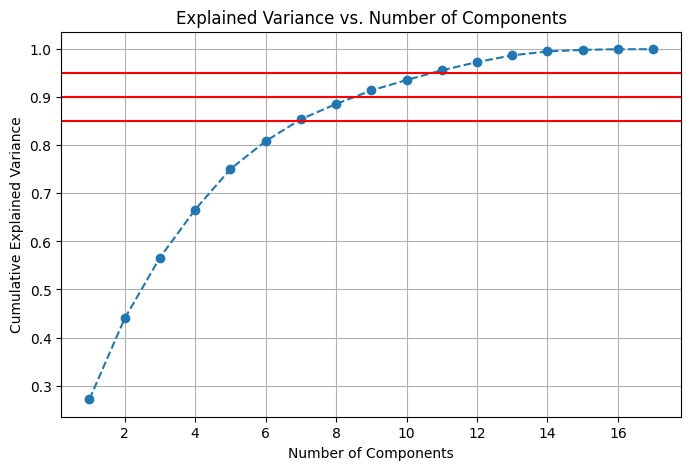

In [33]:
pca=PCA()
x_train_pca=pca.fit_transform(x_train)
explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.axhline(y=0.85, color='r', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()


## 📊 PCA Implementation with 6 Components

In [34]:
pca=PCA(10)
x_train=pca.fit_transform(x_train)
x_val=pca.transform(x_val)
x_test=pca.transform(x_test)

## 🤖 Multiple Model Training and Evaluation

### 📦 Define Models Dictionary
```python
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Rondom Forrest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Evaluation on validation set Logistic Regression:
  Precision: 86.585%
  Accuracy : 86.364%
  ROC-AUC  : 93.269%

Evaluation on validation set Rondom Forrest:
  Precision: 98.750%
  Accuracy : 98.052%
  ROC-AUC  : 99.374%

Evaluation on validation set SVM:
  Precision: 93.506%
  Accuracy : 90.909%
  ROC-AUC  : 96.753%

Evaluation on validation set Decision Tree:
  Precision: 80.220%
  Accuracy : 83.117%
  ROC-AUC  : 88.754%



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

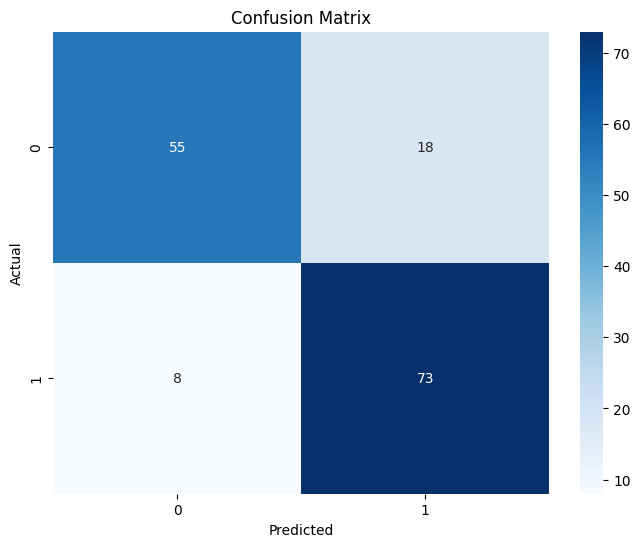

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Rondom Forrest":RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42,max_depth=3)
}


for name, model in models.items():
    model.fit(x_train, y_train)
    y_val_pred = model.predict(x_val)
    y_val_prob = model.predict_proba(x_val)[:,1]

    precision = precision_score(y_val, y_val_pred)
    accuracy  = accuracy_score(y_val, y_val_pred)
    auc       = roc_auc_score(y_val, y_val_prob)
    conf_matrix=  confusion_matrix(y_val, y_val_pred)

    print(f"Evaluation on validation set {name}:")
    print(f"  Precision: {precision*100:.3f}%")
    print(f"  Accuracy : {accuracy*100:.3f}%")
    print(f"  ROC-AUC  : {auc*100:.3f}%\n")
    plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 🧪 Final Model Evaluation on Test Set



Evaluation on validation set Logistic Regression:
  Precision: 81.250%
  Accuracy : 78.571%
  ROC-AUC  : 87.901%
Evaluation on validation set Rondom Forrest:
  Precision: 96.341%
  Accuracy : 95.455%
  ROC-AUC  : 98.184%
Evaluation on validation set SVM:
  Precision: 88.750%
  Accuracy : 86.364%
  ROC-AUC  : 93.908%
Evaluation on validation set Decision Tree:
  Precision: 79.310%
  Accuracy : 79.221%
  ROC-AUC  : 83.973%


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

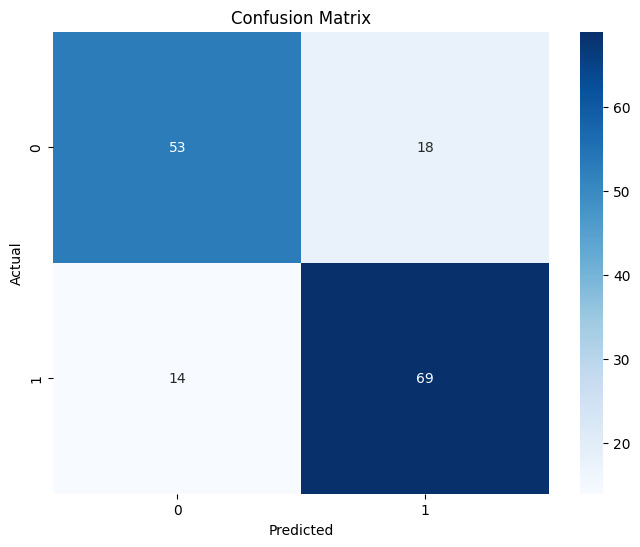

In [37]:
for name, model in models.items():

    y_test_pred = model.predict(x_test)
    y_test_prob = model.predict_proba(x_test)[:,1]

    precision = precision_score(y_test, y_test_pred)
    accuracy  = accuracy_score(y_test, y_test_pred)
    auc       = roc_auc_score(y_test, y_test_prob)
    conf_matrix = confusion_matrix(y_test, y_test_pred)
    print(f"Evaluation on validation set {name}:")
    print(f"  Precision: {precision*100:.3f}%")
    print(f"  Accuracy : {accuracy*100:.3f}%")
    print(f"  ROC-AUC  : {auc*100:.3f}%")
    plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
